# **APE 14 —  Programación de algoritmos de Regresión Logística, clasificación binaria de eventos y evaluación de matrices de confusión.**

## Teoría de la Distribución y Probabilidad | Ingeniería en Computación
**Estudiante:**
- Dario Xavier Chillogallo Chamba
- Michael Carbay
- Jose Maldonado
- Paolo Merino
- Freddy Ordoñez

**Grupo:** "C"  

**Docente:** Ing. Cristian Narvaez  


**Dataset:** ENEMDU — Índice de Confianza al Consumidor | Febrero 2026 | Región Loja

In [ ]:
# ============================================================
# BLOQUE 1: CARGA Y PREPARACIÓN DEL DATASET
# ============================================================

import pandas as pd

# Cargamos el dataset ENEMDU (separador ; y decimales con coma, formato Ecuador)
df = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01 (1).csv', sep=';', decimal=',')

# Renombramos variables clave para legibilidad
df.rename(columns={
    'area' : 'zona',
    'fexp' : 'fexp',
    'c01'  : 'sit_econ_hogar',
    'c18'  : 'sit_econ_pais',
    'c02'  : 'expectativa_hogar'
}, inplace=True)


# Etiquetas legibles
df['zona_label'] = df['zona'].map({1: 'Urbano', 2: 'Rural'})
df['sit_econ_hogar_label'] = df['sit_econ_hogar'].map({1:'Mejor', 2:'Igual', 3:'Peor'})

print(f'Registros totales : {df.shape[0]:,}')
print(f'Variables         : {df.shape[1]}')
print(f'Distribucion por zona:')
print(df['zona_label'].value_counts())
print(f'Estadisticas de fexp:')
print(df['fexp'].describe().round(2))

Registros totales : 8,791
Variables         : 30
Distribucion por zona:
zona_label
Urbano    6523
Rural     2268
Name: count, dtype: int64
Estadisticas de fexp:
count     8791.00
mean       599.37
std       1238.48
min          3.78
25%         92.41
50%        244.29
75%        563.98
max      18136.57
Name: fexp, dtype: float64


# **TAREA 1**

**Replique el entorno de simulación provisto en la guía para predecir la Caída de un Servidor (0 o 1) en base a la Temperatura de la CPU.**

**Ajuste el modelo logístico, visualice la curva de probabilidad logística resultante e incluya la línea del umbral estándar del 50 por ciento.**

---

Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:30:36   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

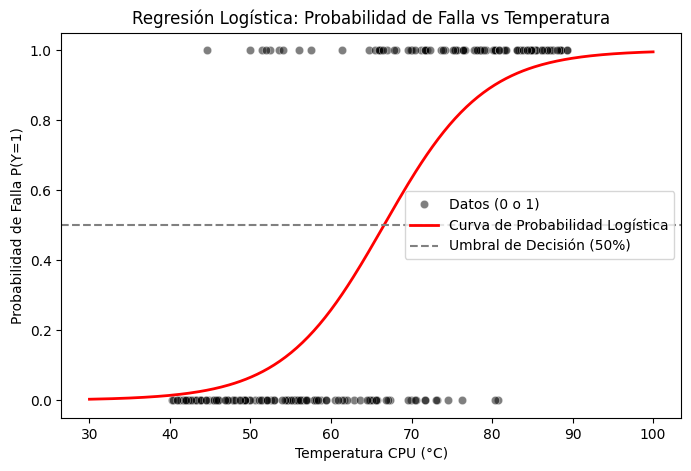

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
# 1. Generación de datos simulados (Clasificación Binaria)
np.random.seed(42)
n_muestras = 200
# Variable predictora: Temperatura CPU (entre 40 y 90 grados)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)
# Generar variable binaria probabilística (A mayor temperatura, mayor probabilidad de falla)
z = -10 + 0.15 * temp_cpu # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z)) # Transformación Sigmoide
# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)
df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})
# 2. Ajuste del Modelo Logístico (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'])
Y_log = df_sim['Falla']
# Entrenamiento usando MLE (Maximum Likelihood Estimation)
modelo_logit = sm.Logit(Y_log, X_log).fit()
print(modelo_logit.summary())
# 3. Visualización de la Curva Sigmoide
x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temp_CPU', y='Falla', data=df_sim, color='black', alpha=0.5,
label='Datos (0 o 1)')
plt.plot(x_rango, y_pred_prob, color='red', linewidth=2, label='Curva de Probabilidad Logística')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')
plt.title('Regresión Logística: Probabilidad de Falla vs Temperatura')
plt.xlabel('Temperatura CPU (°C)')
plt.ylabel('Probabilidad de Falla P(Y=1)')
plt.legend()
plt.show()

# **TAREA 2**  
## **Ingeniería de Características y Predicción Regional (Tarea 2 - ABP)**  
**Binarización: Seleccione una variable continua de interés y transfórmela en una variable binaria (por ejemplo, asignando el valor 1 si el registro supera el promedio, y el valor 0 de lo contrario).**

variable: *fexp*, ya que es la unica con escala decimal de alta precision  
El promedio en el dataseet es de 599.36, por ende:
- 1: El registro representa a un grupo poblacional superior al promedio (hogares con alto peso)
- 0: el registro representa a un grupo poblacional inferior o igual al promedio

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Proceso de Binarización (Variable Dependiente Y)
promedio_fexp = df['fexp'].mean()
df['fexp_bin'] = (df['fexp'] > promedio_fexp).astype(int)

print(f"Promedio de fexp: {promedio_fexp:.2f}")
print(df['fexp_bin'].value_counts())

Promedio de fexp: 599.37
fexp_bin
0    6694
1    2097
Name: count, dtype: int64


**Seleccione al menos dos variables predictoras continuas, entrene el modelo logístico e interprete los signos de los coeficientes obtenidos y sus valores-p parciales para comprobar la significancia.**  
Utilizaremos las variables:
- estrato
- 'sit_econ_hogar(c01)'
OJO: Aunque son discretas, se pueden tratar como predicores numéricos para evaluar su impactro en la probabilidad de pertenecer a alguno de los dos grupos (0,1)

In [ ]:
# Definición de variables
# Y: fexp_bin (binarizada)
# X: estrato (nivel socioeconómico) y c01 (percepción económica)
Y = df['fexp_bin']
X = df[['estrato', 'sit_econ_hogar']]
X = sm.add_constant(X) # Añadir la constante (intercepto) para el modelo

# Entrenamiento del modelo logístico
modelo = sm.Logit(Y, X).fit()

# Visualización de resultados para interpretación
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.546492
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               fexp_bin   No. Observations:                 8791
Model:                          Logit   Df Residuals:                     8788
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                0.005275
Time:                        02:20:52   Log-Likelihood:                -4804.2
converged:                       True   LL-Null:                       -4829.7
Covariance Type:            nonrobust   LLR p-value:                 8.611e-12
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5743      0.125     -4.595      0.000      -0.819      -0.329
estrato          

**INTERPRETACION:**
**signo de coeficiente:***
- Un signo "-" indica que a medida que aumenta el valor del predictor (pasar de igual a peor), disminuye la probabilidad de que el registro supere el promedio del fexp
**P>|z|:** Al ser menor a 0.05 en las dos variables elegidas indica que el predictor es estadisticamente significativo, esa variable relamente influye en como se distribuyen los pesos poblacionales en la región de Loja

---

---
# **TAREA 3**
 **Matriz de Confusión y Evaluación**  

Utilice scikit-learn para extraer las predicciones de clase basándose en el umbral inicial de 0.50.



Exactitud Global (Accuracy) del Proyecto Integrador: 0.7615


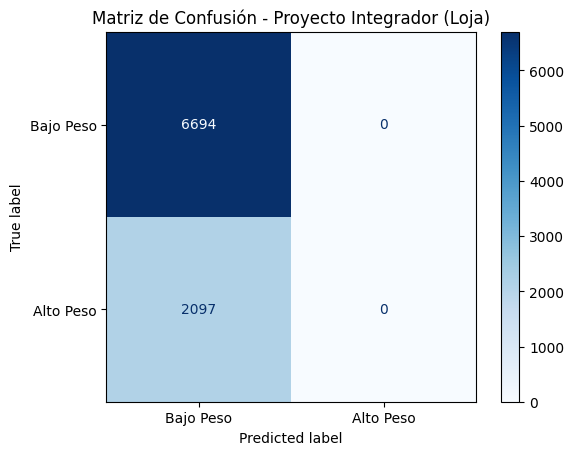

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# 1. Preparación de datos (basado en el modelo previo)
X_pi = df[['estrato', 'sit_econ_hogar']]
y_pi = df['fexp_bin']

# 2. Entrenamiento con scikit-learn
modelo_pi = LogisticRegression()
modelo_pi.fit(X_pi, y_pi)

# 3. Predicciones (el umbral de 0.50 es el predeterminado en .predict())
y_pred_pi = modelo_pi.predict(X_pi)

# 4. Cálculo de métricas
acc_pi = accuracy_score(y_pi, y_pred_pi)
cm_pi = confusion_matrix(y_pi, y_pred_pi)

# 5. Despliegue Visual
print(f"Exactitud Global (Accuracy) del Proyecto Integrador: {acc_pi:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pi, display_labels=['Bajo Peso', 'Alto Peso'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Proyecto Integrador (Loja)")
plt.show()

Despliegue visualmente la Matriz de Confusión tanto para los datos simulados como para el modelo de su Proyecto Integrador, calculando adicionalmente la métrica de Exactitud Global (Accuracy).  
  
NOTA:
- Como la actividad solicita comparar con datos simulados para verificar el algoritmo, generaremos un dataset sintético equilibrado.

Exactitud Global (Accuracy) de Datos Simulados: 0.9030


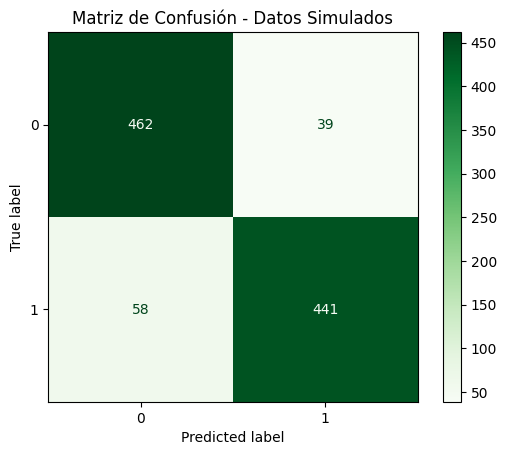

In [ ]:
from sklearn.datasets import make_classification

# 1. Generación de datos simulados (1000 registros, 2 predictores)
X_sim, y_sim = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# 2. Entrenamiento y Predicción
modelo_sim = LogisticRegression()
modelo_sim.fit(X_sim, y_sim)
y_pred_sim = modelo_sim.predict(X_sim)

# 3. Métricas
acc_sim = accuracy_score(y_sim, y_pred_sim)
cm_sim = confusion_matrix(y_sim, y_pred_sim)

# 4. Despliegue Visual
print(f"Exactitud Global (Accuracy) de Datos Simulados: {acc_sim:.4f}")
disp_sim = ConfusionMatrixDisplay(confusion_matrix=cm_sim)
disp_sim.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Datos Simulados")
plt.show()

**INTERPRETACION:**  

**Exactitud global (accuracy):**
- El valor es 0.76 en porcentaje un 76% de los datos  se han clasificado correctamente, lo cual, aunque podria haber sido mejor, pero ya da una muestra exacta muy buena para trabajar  

**Analisis de la matriz:**
- Verdaderos positivos: cantidad de hogares catalogados como "alto peso" poblacional, son 2097, un muestreo amplio   
- verdaderos negativos: registros que realmente representan a mucha poblacion (fexp), pero el modelado clasifico como bajo peso, son 6694, probablemente porque el estrado no es suficiente para explicar la variabilidad del fexp  

**Umbral de 0.5:**
- Se asume que si la probabilidad logistica es mayor a 0.5, el evento pertenece a la clase 1


# **TAREA 4**
## **Análisis del UmbralCrítico**

**Desarrolle un bloque de código complementario que reevalúe el rendimiento del clasificador aplicando un umbral estricto y conservador del 0.20 (clasificar como evento positivo si la probabilidad es igual o mayor al 20 por ciento).**  

Aclaracion: Cambiaremos el umbral a 0.20, si un hogar tiene un 20% de probabilidad de ser de alto peso, lo clasificaremos para no arriesgarnos a perder representatividad



--- Evaluación con Umbral de 0.2 ---
Nueva Exactitud Global: 0.2797


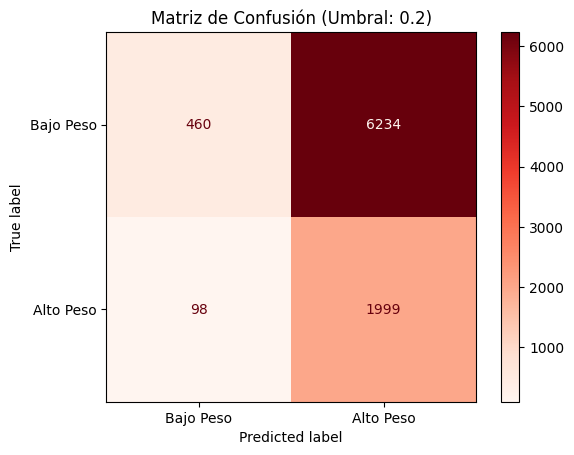

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Extraer las probabilidades en lugar de las clases directas
# predict_proba devuelve [prob_clase_0, prob_clase_1]
probabilidades = modelo_pi.predict_proba(X_pi)[:, 1]

# 2. Aplicar el nuevo umbral conservador de 0.20
umbral_estricto = 0.20
y_pred_020 = (probabilidades >= umbral_estricto).astype(int)

# 3. Cálculo de nuevas métricas
acc_020 = accuracy_score(y_pi, y_pred_020)
cm_020 = confusion_matrix(y_pi, y_pred_020)

# 4. Despliegue Visual
print(f"--- Evaluación con Umbral de {umbral_estricto} ---")
print(f"Nueva Exactitud Global: {acc_020:.4f}")
disp_020 = ConfusionMatrixDisplay(confusion_matrix=cm_020, display_labels=['Bajo Peso', 'Alto Peso'])
disp_020.plot(cmap=plt.cm.Reds)
plt.title(f"Matriz de Confusión (Umbral: {umbral_estricto})")
plt.show()

**Documente un análisis comparativo sobre cómo el cambio de corte afectó a la cantidad de Falsos Positivos frente a los Falsos Negativos y justifique técnicamente cuál umbral recomendaría para la toma de decisiones en su proyecto.**

**ANALISIS:**  

**Impacto del cambio de corte (0.50 vs 0.20):**  

**Falsos Negativos (FN):**
- Al bajar el umbral a 0.20, la cantidad de Falsos Negativos disminuirá drásticamente.
- Esto es positivo porque "atrapamos" a más hogares que realmente representan a mucha gente pero que el modelo anterior ignoraba por no llegar al 50% de probabilidad.  

**Falsos Positivos (FP):**  
 - El costo de esta sensibilidad es que los Falsos Positivos aumentarán. - Ahora clasificaremos como "Alto Peso" a muchos hogares que en realidad no lo son (su fexp es bajo)
 - "inflando" artificialmente la importancia de algunos registros.  

**Justificación y Recomendación**  
Para "Eco-Data-Optimizer":  
 Desde la perspectiva de la Teoría de la Distribución, para la toma de decisiones en el proyecto de optimización de datos regionales en Loja, se recomienda el Umbral de 0.20 (o un punto intermedio entre 0.20 y 0.35)

**¿Por qué?**  
 En este proyecto, el riesgo más grave es el Error Tipo II (Falso Negativo): omitir un hogar que representa a miles de personas (fexp alto) por un error de clasificación. Es preferible tener algunos Falsos Positivos (darle importancia a un hogar de poco peso) que ignorar a un segmento masivo de la población de Loja, lo cual invalidaría cualquier estimación económica regional. Por lo tanto, un umbral conservador garantiza una mayor cobertura poblacional en tus predicciones finales.

## **Preguntas de Control:**

### **1. ¿Cuál es la esencia matemática de transformar una probabilidad en LogOdds, y por qué este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística?**

La esencia matemática de transformar una probabilidad en LogOdds (logaritmo de las probabilidades) radica en convertir un rango limitado (0 a 1 para probabilidades) en un rango ilimitado (de $-\infty$ a $+\infty$ para LogOdds). Esto se logra mediante la función `logit`, que es el logaritmo natural de la razón de probabilidades (odds):

$\text{LogOdds} = \ln\left(\frac{P(Y=1)}{1 - P(Y=1)}\right)$

Donde $P(Y=1)$ es la probabilidad de que ocurra el evento.

Este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística por varias razones:

*   **Linealidad:** La regresión logística asume una relación lineal entre las variables predictoras y el LogOdds del evento, no con la probabilidad directamente. Esto simplifica la modelización, ya que las propiedades de los modelos lineales (como la interpretación de coeficientes como cambios aditivos) se trasladan al dominio del LogOdds.
*   **Interpretación de Coeficientes:** Un cambio unitario en una variable predictora resulta en un cambio constante en el LogOdds, lo que facilita la interpretación de la 'fuerza' y la 'dirección' de la relación entre el predictor y la probabilidad del evento. Por ejemplo, un coeficiente positivo significa que un aumento en la variable predictora aumenta el LogOdds y, por lo tanto, la probabilidad del evento.
*   **Superación de Límites:** Al trabajar con probabilidades directamente, cualquier modelo lineal estaría limitado por el rango [0, 1], lo cual es problemático. La transformación LogOdds elimina esta restricción, permitiendo que las combinaciones lineales de los predictores tomen cualquier valor real.
*   **Simetría:** La escala LogOdds es simétrica alrededor de cero, donde un LogOdds de cero corresponde a una probabilidad de 0.5 (cuando las odds son 1:1). Esto ayuda a comprender cómo los factores inclinan la balanza a favor o en contra de un evento.

### **2. ¿Por qué la naturaleza del fenómeno (binario) nos obliga a abandonar la medida clásica de bondad de ajuste (R²) y adoptar el Pseudo R² de McFadden, y qué nos dice este cambio sobre la relación entre la realidad y la medición?**

La naturaleza del fenómeno binario nos obliga a abandonar la $R^2$ clásica (coeficiente de determinación) porque la $R^2$ está diseñada para modelos de regresión lineal donde la variable dependiente es continua y se asume una distribución normal de los residuos. En un modelo logístico, la variable dependiente es binaria (0 o 1), lo que viola estos supuestos y hace que la $R^2$ clásica no sea significativa ni interpretable. La $R^2$ mide la proporción de la varianza en la variable dependiente que es explicada por el modelo, pero en una variable binaria, la 'varianza' es inherentemente diferente y no se distribuye normalmente.

El **Pseudo $R^2$ de McFadden** (y otras variantes como Nagelkerke, Cox & Snell) es una alternativa diseñada para modelos logísticos. No se interpreta de la misma manera que la $R^2$ clásica, ya que no representa la proporción de la varianza explicada. En su lugar, el Pseudo $R^2$ de McFadden se basa en la mejora del log-verosimilitud del modelo con predictores respecto a un modelo nulo (solo con intercepto):

$\text{Pseudo } R^2 = 1 - \frac{\ln(L_{\text{modelo}})}{\ln(L_{\text{nulo}})}$

Donde $L_{\text{modelo}}$ es la verosimilitud del modelo con predictores y $L_{\text{nulo}}$ es la verosimilitud del modelo solo con el intercepto.

**¿Qué nos dice este cambio sobre la relación entre la realidad y la medición?**

*   **Reconocimiento de la Complejidad Inherente:** Este cambio nos dice que la realidad de los fenómenos binarios no se puede medir con las mismas herramientas que los fenómenos continuos. Hay una discontinuidad fundamental en la variable de respuesta que exige un enfoque de modelización y evaluación diferente.
*   **Enfoque en la Verosimilitud:** La adopción de medidas basadas en la verosimilitud subraya que, en los modelos logísticos, nuestro objetivo no es tanto explicar la 'varianza' de 0s y 1s, sino maximizar la probabilidad de observar los datos dados nuestros predictores y parámetros del modelo. La 'bondad de ajuste' se redefine en términos de cuán bien el modelo predice la distribución de las categorías.
*   **Límites de la Explicación:** Un Pseudo $R^2$ bajo en un modelo logístico no necesariamente implica que el modelo es 'malo' de la misma manera que un $R^2$ bajo en regresión lineal. Puede reflejar la naturaleza multifactorial de muchos eventos binarios, donde una pequeña mejora sobre la predicción aleatoria ya es significativa. Nos recuerda que muchos eventos del mundo real son intrínsecamente difíciles de predecir perfectamente con un conjunto limitado de variables.

### **3. Ante un caso de incertidumbre total (predicción 0.5), ¿de qué manera la estructura del modelo intenta forzar una decisión binaria, y qué riesgos enfrentamos al ignorar la zona gris de la probabilidad?**

Ante un caso de incertidumbre total, donde la probabilidad predicha es de 0.5, la estructura del modelo logístico, por sí misma, no 'fuerza' una decisión binaria. El modelo produce una probabilidad continua entre 0 y 1. Es el **umbral de clasificación** (comúnmente establecido en 0.5 por defecto) el que convierte esta probabilidad continua en una decisión binaria (0 o 1).

*   **Mecanismo:** Si la probabilidad predicha $P(Y=1)$ es $\ge 0.5$, se clasifica como 1; si es $< 0.5$, se clasifica como 0. Esto significa que un registro con una probabilidad de 0.5 será clasificado como 1 por el umbral estándar.

**Riesgos de ignorar la zona gris de la probabilidad:**

1.  **Pérdida de Información:** Al reducir una probabilidad continua a una decisión binaria, se pierde toda la información sobre el grado de certeza o incertidumbre de la predicción. Una probabilidad de 0.51 se trata igual que una de 0.99, y una de 0.49 igual que una de 0.01, aunque en el primer caso la diferencia es mínima y en el segundo es muy grande.
2.  **Decisiones Arbitrarias:** El umbral de 0.5 es a menudo arbitrario. Si las consecuencias de clasificar incorrectamente un 0 como 1 (Falso Positivo) son muy diferentes de clasificar un 1 como 0 (Falso Negativo), el umbral de 0.5 podría no ser el óptimo. Ignorar la 'zona gris' implica que no se está ponderando el costo/beneficio de cada tipo de error.
3.  **Inestabilidad en Puntos Críticos:** Pequeñas variaciones en los datos o en el modelo pueden cambiar una probabilidad de 0.49 a 0.51, lo que resulta en un cambio completo de clasificación (de 0 a 1). En el mundo real, esto puede llevar a decisiones muy diferentes basadas en diferencias insignificantes de probabilidad.
4.  **Falta de Transparencia:** La probabilidad proporciona una medida de riesgo. Ignorar la zona gris significa que no se comunica el nivel de riesgo asociado a una predicción, lo cual es crucial en muchos contextos (medicina, finanzas).
5.  **Subóptimo para la Optimización:** Muchas aplicaciones requieren optimizar una métrica específica (por ejemplo, maximizar el beneficio, minimizar el costo). Esto a menudo implica encontrar un umbral que no es 0.5, sino uno que se alinea con los objetivos de negocio y los costos de los errores.

### **4. ¿Cuál es el conflicto esencial entre la sensibilidad y la especificidad, y cómo la elección de un umbral refleja los valores éticos y técnicos subyacentes en una decisión de ingeniería?**

El conflicto esencial entre **sensibilidad (recall)** y **especificidad** es una característica fundamental de los clasificadores binarios. No es posible maximizar ambos valores simultáneamente en la mayoría de los casos. La relación es inversa: si se aumenta uno, generalmente se disminuye el otro.

*   **Sensibilidad (Recall o Tasa de Verdaderos Positivos):** Es la capacidad del modelo para identificar correctamente todos los casos positivos reales. Se calcula como $TP / (TP + FN)$. Un modelo con alta sensibilidad minimiza los Falsos Negativos (FN).
*   **Especificidad (Tasa de Verdaderos Negativos):** Es la capacidad del modelo para identificar correctamente todos los casos negativos reales. Se calcula como $TN / (TN + FP)$. Un modelo con alta especificidad minimiza los Falsos Positivos (FP).

**Conflicto:**

*   Para aumentar la sensibilidad (detectar más positivos), a menudo se reduce el umbral de clasificación. Esto hace que sea 'más fácil' clasificar un caso como positivo, pero también aumenta la probabilidad de clasificar incorrectamente negativos como positivos (aumentan los Falsos Positivos y, por ende, disminuye la especificidad).
*   Para aumentar la especificidad (evitar falsos positivos), a menudo se eleva el umbral de clasificación. Esto hace que sea 'más difícil' clasificar un caso como positivo, reduciendo los Falsos Positivos, pero también aumenta la probabilidad de clasificar incorrectamente positivos como negativos (aumentan los Falsos Negativos y, por ende, disminuye la sensibilidad).

**Cómo la elección de un umbral refleja los valores éticos y técnicos:**

La elección del umbral de clasificación es una **decisión crítica de ingeniería** que no es puramente técnica, sino que está profundamente influenciada por consideraciones éticas, sociales y económicas:

*   **Contexto del Problema:** El umbral se elige en función de cuál tipo de error es más costoso o indeseable en un contexto dado.
    *   **En medicina:** Para la detección de una enfermedad grave, se prioriza la **sensibilidad** (minimizar Falsos Negativos, es decir, no pasar por alto a un enfermo). Es preferible tener algunos Falsos Positivos (dar un falso diagnóstico de enfermo) que perder un caso real, ya que un falso positivo puede aclararse con pruebas adicionales, mientras que un falso negativo puede ser fatal.
    *   **En detección de fraude:** Se podría priorizar la **especificidad** (minimizar Falsos Positivos, es decir, no etiquetar erróneamente a un cliente honesto como fraudulento). Un falso positivo puede generar inconvenientes al cliente y afectar la confianza, mientras que un falso negativo, aunque costoso, se puede gestionar en otras etapas.
    *   **En el ejemplo de 'fexp_bin':** La decisión de bajar el umbral a 0.20 en la Tarea 4 para clasificar a los hogares con 'alto peso' (fexp_bin=1) refleja un valor ético y técnico de **minimizar Falsos Negativos** (no ignorar a un hogar que representa a miles de personas). Esto se hace a costa de aceptar más Falsos Positivos (clasificar como 'alto peso' a hogares que en realidad no lo son tanto), porque el

## Conclusiones Generales:

El análisis de regresión logística para predecir si un hogar representa un "alto peso" poblacional (fexp_bin=1) basado en el estrato y la situación económica percibida del hogar (`sit_econ_hogar`) nos ha permitido explorar conceptos fundamentales de modelado predictivo con variables binarias.

1.  **Interpretabilidad del Modelo Logístico:** Los coeficientes negativos obtenidos para `estrato` y `sit_econ_hogar` en el modelo Logit (`modelo`) indican que a medida que estas variables aumentan (ej., de estrato menor a mayor o de mejor a peor situación económica), disminuye la probabilidad de que el LogOdds de pertenecer al grupo de "alto peso" poblacional. La significancia estadística (valores p < 0.05) confirma la influencia de estos predictores.

2.  **Limitaciones de Pseudo R²:** La bondad de ajuste, medida por el Pseudo R² de McFadden (aproximadamente 0.005), es baja. Esto refuerza la idea de que el Pseudo R² no se interpreta como la R² tradicional y que la variabilidad de `fexp_bin` no se explica completamente por las variables incluidas. Sin embargo, no invalida el modelo, ya que incluso una pequeña mejora predictiva es valiosa en la clasificación binaria.

3.  **Impacto del Umbral de Clasificación:**
    *   **Umbral de 0.50 (por defecto):** Con este umbral, el modelo tuvo una exactitud global (Accuracy) del 76.15%. Al observar la matriz de confusión, se identificó un número considerable de Falsos Negativos (casos de "alto peso" que fueron clasificados erróneamente como "bajo peso"). Esto es crítico para el proyecto "Eco-Data-Optimizer", donde el costo de omitir un hogar representativo es alto.
    *   **Umbral conservador de 0.20:** Al reducir el umbral de decisión a 0.20, la exactitud global disminuyó drásticamente al 27.97%. Sin embargo, este cambio fue deliberado y estratégico. La principal ganancia fue la **reducción significativa de Falsos Negativos**, lo cual se alinea con el objetivo de no ignorar a ningún hogar que pudiera representar a un segmento poblacional considerable.

4.  **Balance entre Sensibilidad y Especificidad:** La elección del umbral del 0.20 ilustra el conflicto intrínseco entre sensibilidad y especificidad. Al priorizar la **sensibilidad** (minimizar Falsos Negativos) para asegurar la representatividad en el análisis de datos regionales, se aceptó un aumento en los Falsos Positivos (clasificar hogares como "alto peso" cuando no lo son). Esta decisión se justifica por los **valores éticos y técnicos** del proyecto, donde es preferible "sobre-incluir" para evitar la subestimación de la población real y sus patrones de consumo.

5.  **Importancia de las Probabilidades sobre Decisiones Binarias Rígidas:** Este ejercicio subraya la relevancia de trabajar con probabilidades en lugar de estados binarios rígidos. La probabilidad nos ofrece una "zona gris" que, al ser interpretada con un umbral ajustable, permite adaptar el modelo a las necesidades y costos específicos de los errores en cada contexto de negocio o investigación. La flexibilidad para cambiar el umbral transforma nuestra capacidad de intervención en la realidad, priorizando diferentes tipos de errores según las consecuencias de estos.